# Regression 

A technique which shows the relationship between variable 'y' based on the value of variables 'x'

### Example

People buy more jackets in winter

- X = Winter is an independent variable
- Y = Sale of jacket

_where Y is dependent on X_


People buy more icecreams in summer

- X = Summer is an independent variable
- Y = Sale of ice cream

_where Y is dependent on X_


## Calculation

For the given values x & y,

x = [1, 2, 3, 4, 5]
y = [4, 3, 4, 2, 5]

- Equation of line (y) = mx+c
- m = Σ((x-mean(x))(y-mean(y)))/Σ(x-mean(x)^2)
- mean(x) = 15/5 = 3
- mean(y) = 18/5 = 3.6

|   (x) | (y) | (x-\bar{x}) | (y-\bar{y}) | ((x-\bar{x})(y-\bar{y})) | ((x-\bar{x})^2) |
| ------: | ----: | ------------: | ------------: | ---------------------------: | ----------------: |
|       1 |     4 |            -2 |           0.4 |                         -0.8 |                 4 |
|       2 |     3 |            -1 |          -0.6 |                          0.6 |                 1 |
|       3 |     4 |             0 |           0.4 |                            0 |                 0 |
|       4 |     2 |             1 |          -1.6 |                         -1.6 |                 1 |
|       5 |     5 |             2 |           1.4 |                          2.8 |                 4 |
| **Sum** |       |               |               |                      **1.0** |            **10** |

#### The next step is to calculate the intercept:
- m = 1.0/10 = 0.1
- c = bar{y} - m*bar{x} = 3.6−(0.1)(3)=3.3
- y = 0.1x + 3.3

### Line of Regression
#### Let's predict for Y when given values of X, [y = Actual Distance, yP = Predicted Distance]
- x = 1, yP = 3.4
- x = 2, yP = 3.5
- x = 3, yP = 3.6
- x = 4, yP = 3.7
- x = 5, yP = 3.8

### Finding the best fit line

#### Goodness of fit - R

R^2 = Σ((yP - \bar{y})^2 / Σ(y - \bar{y})^2)

|   (x) | (y) | yP | (yP-\bar{y}) | (y-\bar{y}) | ((yP-\bar{y})^2) | ((y-\bar{y})^2) |
| ------: | ----: | ------------: | ------------: | ---------------------------: | ----------------: | ----------------: |
|       1 |     4 |           3.4 |          -0.2 |                          0.4 |              0.04 |              0.16 |
|       2 |     3 |           3.5 |          -0.1 |                         -0.6 |              0.01 |              0.36 |
|       3 |     4 |           3.6 |           0.0 |                          0.4 |                 0 |              0.16 |
|       4 |     2 |           3.7 |           0.1 |                         -1.6 |              0.01 |              2.56 |
|       5 |     5 |           3.8 |           0.2 |                          1.4 |              0.04 |              1.96 |
| **Sum** |       |               |               |                              |          **0.10** |           **5.2** |

- **R^2 = Σ(yP - \bar{y})^2 / Σ(y - \bar{y})^2**

### More the value of R^2, the more is strong relation/dependency between x and y
### Less the value of R^2, the less relation/dependency between x and y
### Less the value of R^2, the line of regression overlaps R2(good fit line)

In [2]:
# Linear Regression in Python

import numpy as np
import matplotlib.pyplot as plt

estimate_coefficients: 
b0 = -13.333333333333485, 
b1 = 204.24242424242425


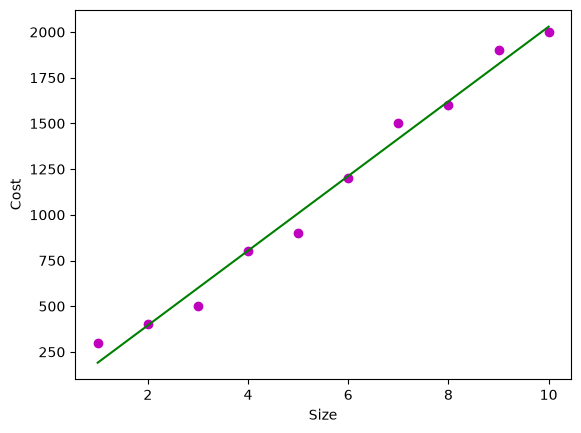

In [11]:
'''
The goal is to find a line [y=b0+b1x] where:

b0 = intercept
b1 = slope # Every increase of one unit in size increases price by Some value (in this example : by 204).
'''


def estimate_coefficients(x, y):
    n = np.size(x)
    mean_x, mean_y = np.mean(x), np.mean(y) 
    SS_xy = np.sum(x * y) - n * mean_x * mean_y # sum of squared errors
    SS_xx = np.sum(x*x) - n * mean_x * mean_x # sum of squared errors
    b1 = SS_xy / SS_xx
    b0 = mean_y - b1 * mean_x
    return(b0, b1)

def plot_regression_line(x, y, b):
    plt.scatter(x, y, color='m', marker='o')
    pred = b[0]+b[1]*x
    plt.plot(x, pred, color='g')
    plt.xlabel('Size')
    plt.ylabel('Cost')
    plt.show()

x = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9, 10])
y = np.array([300, 400, 500, 800, 900, 1200, 1500, 1600, 1900, 2000])

b = estimate_coefficients(x, y)
print("estimate_coefficients: \nb0 = {}, \nb1 = {}".format(b[0], b[1]))
plot_regression_line(x, y, b)

# Linear Regression Demo

## # Lower the RMSE(Root Mean Squared Error) , better the model

In [12]:
import pandas as pd
data = pd.read_csv('./datasets/Boston.csv')
data.head()

,rownames,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [13]:
data.shape

(506, 15)

In [14]:
data.describe()

,rownames,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,253.500000,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,146.213884,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,1.000000,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,127.250000,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,253.500000,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,379.750000,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,506.000000,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [16]:
# medv - Median price value of houses in boston - **Dependent variable**
# lstat - percent of population below poverty line - **Independent variable**
data_ = data.loc[:, ['lstat', 'medv']]
data_.head(5)

,lstat,medv
0,4.98,24.0
1,9.14,21.6
2,4.03,34.7
3,2.94,33.4
4,5.33,36.2


# Visualizing Variables

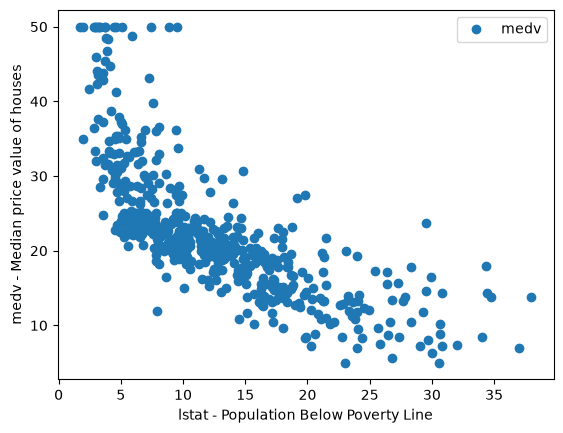

In [18]:
import matplotlib.pyplot as plt
data.plot(x='lstat', y='medv', style='o')
plt.xlabel('lstat - Population Below Poverty Line')
plt.ylabel('medv - Median price value of houses')
plt.show()

# Preparing Data

In [19]:
X = pd.DataFrame(data['lstat'])
Y = pd.DataFrame(data['medv'])

In [20]:
X.size, Y.size

(506, 506)

In [22]:
from sklearn.model_selection import train_test_split
# test_size - % of record in test set and rest in training set, 20% in this case
# radom_state = 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=1)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(404, 1)
(102, 1)
(404, 1)
(102, 1)


In [25]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-0.92]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['lstat']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[34.33]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [31]:
Y_pred = regressor.predict(X_test)
Y_pred = pd.DataFrame(y_pred, columns=['Predicted'])

from sklearn import metrics
import numpy as np

print('Mean Absolute Error: ', metrics.mean_absolute_error(Y_test, y_pred))
print('Mean Squared Error: ', metrics.mean_squared_error(Y_test, y_pred))
print('Root Mean Squared Error: ', np.sqrt(metrics.mean_squared_error(Y_test, y_pred)))

# Lower the RMSE(Root Mean Squared Error) , better the model , also used in multiple model comaprisons

Mean Absolute Error:  5.078127727696937
Mean Squared Error:  46.994820919547124
Root Mean Squared Error:  6.855276866731724


# Multiple Linear Regression

In [34]:
import pandas as pd
import numpy as np
dataset = pd.read_csv('./datasets/Boston.csv')
dataset.head()

,rownames,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
X = pd.DataFrame(dataset.iloc([:, :-1])) # select all columns except last one
Y = pd.DataFrame(dataset.iloc([:, -1])) # selects only last column

In [35]:
from sklearn.model_selection import train_test_split
# test_size - % of record in test set and rest in training set, 30% in this case
# radom_state = 
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=1)
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(354, 1)
(152, 1)
(354, 1)
(152, 1)


In [36]:
from sklearn.linear_model import LinearRegression
regressor = LinearRegression()
regressor.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[-0.92]]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['lstat']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[34.22]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [40]:
Y_pred = regressor.predict(X_test)
Y_pred = pd.DataFrame(Y_pred, columns=['Predicted'])

In [42]:
from sklearn import metrics
import numpy as np

print('Mean Absolute Error: ', metrics.mean_absolute_error(Y_test, Y_pred))
print('Mean Squared Error: ', metrics.mean_squared_error(Y_test, Y_pred))
print('Root Mean Squared Error: ', np.sqrt(metrics.mean_squared_error(Y_test, Y_pred)))

# Lower the RMSE(Root Mean Squared Error) , better the model , also used in multiple model comaprisons

Mean Absolute Error:  4.815209094507989
Mean Squared Error:  42.62024347153971
Root Mean Squared Error:  6.528418144661057


# Logistic Regression

- A statistical classification model
- Deals with categorical dependent variable
- could be binary or dichotomous
- Could be multinomial
- Takes both continuous and discrete input data